# Baseline Model - Logistic Regression

This notebook trains a Logistic Regression model as the baseline for the Disease
Risk Prediction System. The goal is to establish a minimum performance benchmark
that all subsequent models must improve upon. Evaluation goes beyond accuracy to
include precision, recall, F1-score and cross-validation to ensure results are
stable and clinically meaningful.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score

file_path = r"C:\Courses\DAMG6105\Project - Disease Prediction System"

# Load processed splits
X_train = pd.read_csv(f'{file_path}/data/processed/X_train.csv')
X_val = pd.read_csv(f'{file_path}/data/processed/X_val.csv')
X_test = pd.read_csv(f'{file_path}/data/processed/X_test.csv')
y_train = pd.read_csv(f'{file_path}/data/processed/y_train.csv').squeeze()
y_val = pd.read_csv(f'{file_path}/data/processed/y_val.csv').squeeze()
y_test = pd.read_csv(f'{file_path}/data/processed/y_test.csv').squeeze()

print("Data loaded successfully.")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("Scaled data loaded successfully.")
print("\nSample of loaded data:")
print(X_train[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].describe().round(2))


Data loaded successfully.
X_train shape: (644, 15)
X_val shape: (138, 15)
X_test shape: (138, 15)
Scaled data loaded successfully.

Sample of loaded data:
          age  trestbps    chol  thalch  oldpeak
count  644.00    644.00  644.00  644.00   644.00
mean    -0.00     -0.00    0.04    0.00    -0.00
std      1.00      1.00    0.88    1.00     1.00
min     -2.63     -6.88   -1.53   -2.96    -3.28
25%     -0.75     -0.60   -0.24   -0.69    -0.83
50%      0.08     -0.08    0.23    0.07    -0.26
75%      0.71      0.44    0.62    0.70     0.59
max      2.48      3.58    1.91    2.58     5.02


In [7]:
# Train Logistic Regression baseline model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions on validation set
y_pred = lr_model.predict(X_val)

print("Model trained successfully.")
print("\nSample predictions (first 10):")
print("Predicted:", y_pred[:10])
print("Actual:   ", y_val.values[:10])

Model trained successfully.

Sample predictions (first 10):
Predicted: [0 1 1 0 0 1 1 1 1 0]
Actual:    [0 1 1 0 0 1 1 1 1 0]


In [8]:
# Evaluate model on validation set
print("=== Logistic Regression - Validation Set Performance ===\n")
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred):.4f}")
print("\nFull Classification Report:")
print(classification_report(y_val, y_pred))

=== Logistic Regression — Validation Set Performance ===

Accuracy:  0.8696
Precision: 0.8642
Recall:    0.9091
F1 Score:  0.8861

Full Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        61
           1       0.86      0.91      0.89        77

    accuracy                           0.87       138
   macro avg       0.87      0.86      0.87       138
weighted avg       0.87      0.87      0.87       138



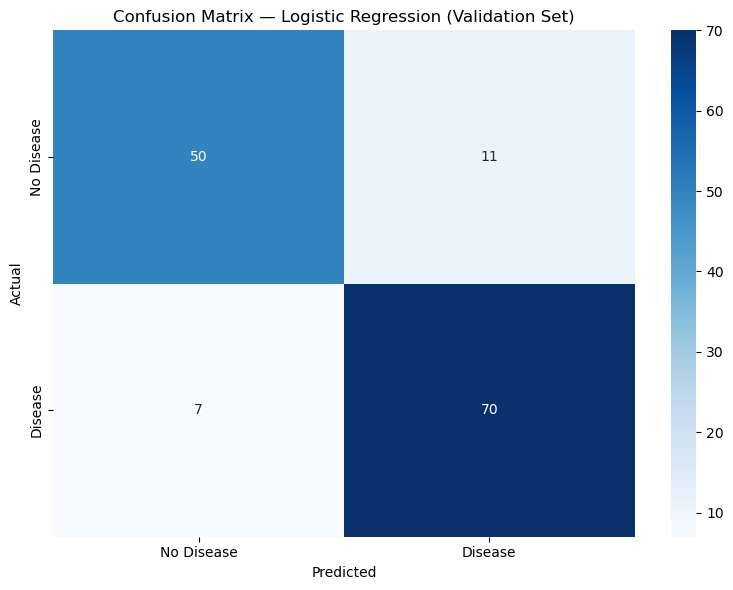

True Negatives  (correctly predicted no disease): 50
False Positives (healthy predicted as disease):   11
False Negatives (missed diagnoses):               7
True Positives  (correctly predicted disease):    70


In [9]:
# Confusion matrix visualization
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Logistic Regression (Validation Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/lr_confusion_matrix.png')
plt.show()

# Print exact values for reference
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted no disease): {tn}")
print(f"False Positives (healthy predicted as disease):   {fp}")
print(f"False Negatives (missed diagnoses):               {fn}")
print(f"True Positives  (correctly predicted disease):    {tp}")

## Logistic Regression - Validation Set Results

| Metric | Score |
|---|---|
| Accuracy | 0.8696 |
| Precision | 0.8642 |
| Recall | 0.9091 |
| F1 Score | 0.8861 |

### Key Observations
- The model correctly identified 70 out of 77 disease patients (91% recall), making only 7 missed diagnoses - the most critical error type in a clinical setting.
- Healthy patients were correctly identified 82% of the time, producing 11 false alarms - patients flagged as sick who are actually healthy.
- The model naturally prioritizes disease detection over healthy classification, which is the ideal trade-off for a medical screening tool.
- Overall performance of 87% accuracy is strong for a baseline model and sets a competitive benchmark for advanced models to beat.

In [10]:
# Cross validation on training data
cv_scores = cross_val_score(lr_model, X_train, y_train, 
                            cv=5, scoring='recall')

print("=== 5-Fold Cross Validation Results ===\n")
print("Recall score per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
    
print(f"\nMean Recall:  {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

=== 5-Fold Cross Validation Results ===

Recall score per fold:
  Fold 1: 0.8169
  Fold 2: 0.8732
  Fold 3: 0.8169
  Fold 4: 0.8333
  Fold 5: 0.8310

Mean Recall:  0.8343
Std Deviation: 0.0207


## Cross Validation Results

| Metric | Score |
|---|---|
| Fold 1 Recall | 0.8169 |
| Fold 2 Recall | 0.8732 |
| Fold 3 Recall | 0.8169 |
| Fold 4 Recall | 0.8333 |
| Fold 5 Recall | 0.8310 |
| Mean Recall | 0.8343 |
| Std Deviation | 0.0207 |

### Key Observations
- Cross validated mean recall of 0.8343 is lower than the single validation recall of 0.9091, suggesting the single validation score was slightly optimistic.
- Low standard deviation of 0.0207 confirms the model performs consistently across different subsets of training data - a sign of stable, reliable learning.
- The cross validated score of 0.83 is the more honest estimate of real world performance and will be used as the baseline benchmark for advanced models.

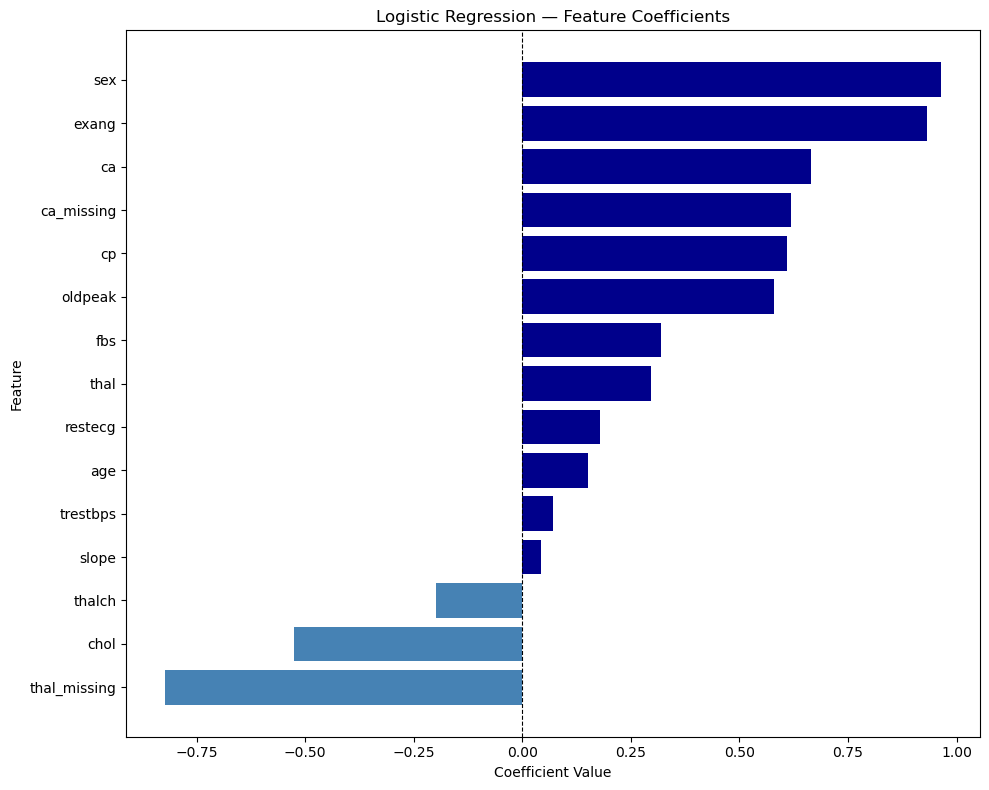

Feature Coefficients (sorted by absolute impact):
     Feature  Coefficient
         sex     0.964619
       exang     0.932272
thal_missing    -0.823159
          ca     0.665797
  ca_missing     0.618988
          cp     0.609167
     oldpeak     0.579540
        chol    -0.527065
         fbs     0.318749
        thal     0.296046
      thalch    -0.198655
     restecg     0.179950
         age     0.151913
    trestbps     0.070788
       slope     0.043705


In [11]:
# Extract feature coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = ['darkblue' if c > 0 else 'steelblue' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.title('Logistic Regression — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{file_path}/outputs/figures/lr_coefficients.png')
plt.show()

# Print exact values
print("Feature Coefficients (sorted by absolute impact):")
print(coefficients.reindex(
    coefficients['Coefficient'].abs().sort_values(ascending=False).index
).to_string(index=False))

## Feature Coefficients Analysis

### Strongest Positive Predictors (push toward disease)
- `sex` (0.965) and `exang` (0.932) are the strongest positive predictors, consistent with EDA findings - being male and having exercise induced angina
  are the strongest indicators of disease presence.
- `ca` (0.666), `ca_missing` (0.619), and `cp` (0.609) also show strong positive influence, aligning with clinical expectations.

### Strongest Negative Predictors (push away from disease)
- `thal_missing` (-0.823) is the strongest negative predictor - patients whose thal value was missing are strongly predicted as no disease, suggesting
  missingness in thal may indicate patients considered low risk and therefore not tested.
- `chol` (-0.527) shows a negative coefficient, consistent with the counterintuitive negative correlation observed in EDA - confirming cholesterol
  as an unreliable predictor in this dataset.
- `thalch` (-0.199) shows a weaker coefficient than its EDA correlation suggested. This is expected - correlation measures each feature independently, while coefficients reflect contribution after accounting for all other features.

### EDA Validation
- The model largely confirms EDA hypotheses - features with strong correlations generally show larger coefficients.
- Key difference: `thal_missing` emerged as more influential than `thalch`, validating our preprocessing decision to add missing indicators.

# Notebook 04 Summary - Baseline Model

## Model
- Algorithm: Logistic Regression
- Training set: 644 patients
- Validation set: 138 patients

## Performance
| Metric | Validation Score | Cross Validated Score |
|---|---|---|
| Accuracy | 0.8696 | — |
| Recall | 0.9091 | 0.8343 |
| Precision | 0.8642 | — |
| F1 Score | 0.8861 | — |

## Key Findings
- Strong baseline performance with 91% recall on validation set - Cross validated recall of 0.83 provides a more conservative and honest
  estimate of real world performance
- Only 7 missed diagnoses out of 77 actual disease patients
- `sex` and `exang` emerged as the strongest positive predictors
- `thal_missing` surprisingly emerged as the strongest negative predictor, validating the missing indicator preprocessing decision
- All advanced models in notebook 05 must beat a cross validated recall of 0.8343 to justify added complexity

In [12]:
import pickle

# Save trained model
model_path = f'{file_path}/outputs/models/logistic_regression.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)

print("Logistic Regression model saved successfully.")
print(f"Saved to: {model_path}")

Logistic Regression model saved successfully.
Saved to: C:\Courses\DAMG6105\Project - Disease Prediction System/outputs/models/logistic_regression.pkl
